In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
from collections import defaultdict
from config import TRAINING_DATA_DIR
from config import PATCH_SIZE

In [3]:
base_dir = TRAINING_DATA_DIR

In [4]:
mitotic_files = list((base_dir / 'mitotic').glob("*.png"))
non_mitotic_files = list((base_dir / 'non_mitotic').glob("*.png"))

print(f"Mitotic: {len(mitotic_files)}")
print(f"Non-mitotic: {len(non_mitotic_files)}")
print(f"Total: {len(mitotic_files) + len(non_mitotic_files)}")
print(f"Imbalance ratio: {len(non_mitotic_files) / len(mitotic_files):.1f}:1")

Mitotic: 21036
Non-mitotic: 125194
Total: 146230
Imbalance ratio: 6.0:1


In [5]:
mitotic_labels = set(f.stem.split('_')[-1] for f in mitotic_files)
non_mitotic_labels = set(f.stem.split('_')[-1] for f in non_mitotic_files)

print(f"Labels in mitotic folder: {mitotic_labels}")
print(f"Labels in non-mitotic folder: {non_mitotic_labels}")

Labels in mitotic folder: {'2'}
Labels in non-mitotic folder: {'7', '3', '4', '1'}


In [6]:
from collections import Counter

non_mitotic_labels_counts = Counter(f.stem.split('_')[-1] for f in non_mitotic_files)
print(non_mitotic_labels_counts)

Counter({'3': 45178, '4': 41656, '1': 35331, '7': 3029})


In [7]:
# do you keep all non-mitotic classes, drop class 4, or treat them differently? 

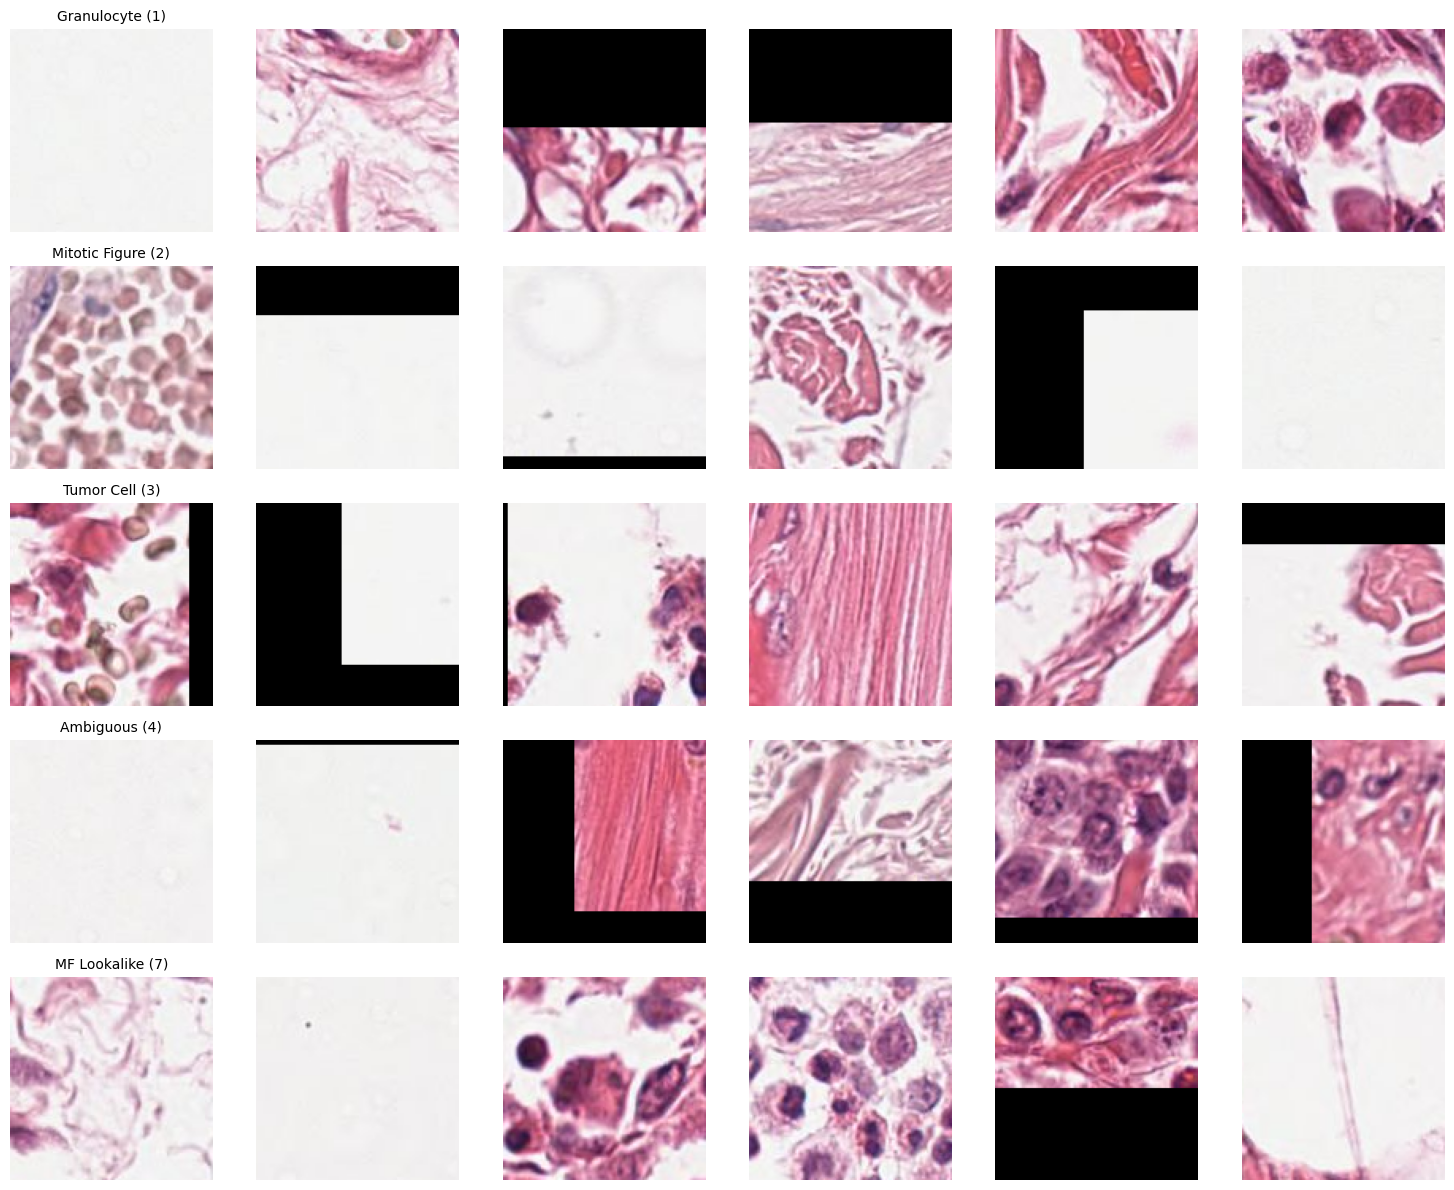

In [8]:
class_files = defaultdict(list)
for f in mitotic_files + non_mitotic_files:
    label = f.stem.split('_')[-1]
    class_files[label].append(f)

class_names = {
    "1": "Granulocyte",
    "2": "Mitotic Figure",
    "3": "Tumor Cell",
    "4": "Ambiguous",
    "7": "MF Lookalike"
}

fig, axes = plt.subplots(5, 6, figsize=(15, 12))
for row, (label, name) in enumerate(class_names.items()):
    samples = random.sample(class_files[label], 6)
    for col, f in enumerate(samples):
        img = cv2.imread(str(f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img)
        axes[row][col].axis("off")
        if col == 0:
            axes[row][col].set_title(f"{name} ({label})", fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
black_patches = 0
blank_patches = 0
total_checked = 0

all_files = mitotic_files + non_mitotic_files
sample = random.sample(all_files, min(5000, len(all_files)))

for f in sample:
    img = cv2.imread(str(f))
    if img is None:
        continue
    total_checked += 1

    black_ratio = np.mean(np.all(img == 0, axis=2))
    if black_ratio > 0.1:
        black_patches += 1

    if img.mean() > 220:
        blank_patches += 1

print(f"Checked: {total_checked}")
print(f"Black padding >10%: {black_patches} ({100*black_patches/total_checked:.1f}%)")
print(f"Near-blank: {blank_patches} ({100*blank_patches/total_checked:.1f}%)")

Checked: 5000
Black padding >10%: 1874 (37.5%)
Near-blank: 1263 (25.3%)


In [10]:
for label, name in class_names.items():
    
    files = class_files[label]
    sample = random.sample(files, min(1000, len(all_files)))

    black = 0
    blank = 0
    checked = 0
    
    for f in sample:
        
        img = cv2.imread(str(f))
        if img is None:
            continue
        checked += 1
    
        black_ratio = np.mean(np.all(img == 0, axis=2))
        if black_ratio > 0.1:
            black += 1
    
        if img.mean() > 220:
            blank += 1

    print(f"{name:20s} | Black: {100*black/checked:5.1f}% | Blank: {100*blank/checked:5.1f}% | Sampled: {checked}")

Granulocyte          | Black:  40.2% | Blank:  29.6% | Sampled: 1000
Mitotic Figure       | Black:  36.3% | Blank:  19.3% | Sampled: 1000
Tumor Cell           | Black:  39.4% | Blank:  23.1% | Sampled: 1000
Ambiguous            | Black:  40.3% | Blank:  26.0% | Sampled: 1000
MF Lookalike         | Black:  36.7% | Blank:  19.5% | Sampled: 1000


In [12]:
clean_counts = {}
clean_files = defaultdict(list)

for label, name in class_names.items():
    
    files = class_files[label]

    clean = 0
    total = 0
    
    for f in files:
        
        img = cv2.imread(str(f))
        if img is None:
            continue
        total += 1
    
        black_ratio = np.mean(np.all(img == 0, axis=2))
        if black_ratio > 0.2:
            continue
    
        if img.mean() > 220:
            continue

        clean += 1
        clean_files[label].append(f)
        
    clean_counts[label] = clean
    print(f"{name:20s} | Total: {total:6d} | Clean: {clean:6d} | Dropped: {total - clean:6d}")

print(f"\n{'TOTAL':20s} | Total: {sum(len(class_files[l]) for l in class_names):6d} | Clean: {sum(clean_counts.values()):6d}")

Granulocyte          | Total:  35331 | Clean:  14120 | Dropped:  21211
Mitotic Figure       | Total:  21036 | Clean:  11344 | Dropped:   9692
Tumor Cell           | Total:  45178 | Clean:  21407 | Dropped:  23771
Ambiguous            | Total:  41656 | Clean:  18172 | Dropped:  23484
MF Lookalike         | Total:   3029 | Clean:   1563 | Dropped:   1466

TOTAL                | Total: 146230 | Clean:  66606


In [16]:
bad_size = 0
sample = random.sample(clean_files["2"], min(500, len(clean_files["2"])))

for f in sample:
    img = cv2.imread(str(f))
    if img is not None and img.shape != (PATCH_SIZE, PATCH_SIZE, 3):
        bad_size += 1
        print(f"Bad shape: {img.shape} - {f.name}")

print(f"Bad sizes: {bad_size}/{len(sample)}")

Bad sizes: 0/500


In [17]:
with open(base_dir / "clean_paths.txt", "w") as f:
    for label in clean_files:
        for path in clean_files[label]:
            f.write(f"{label},{path.name}\n")

print(f"Saved {sum(len(v) for v in clean_files.values())} clean paths")

Saved 66606 clean paths
